In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.coupling import apply_node_lesions, plot_lesioned_coupling
from kuramoto.simulation import KuramotoParams
from kuramoto.analysis import (
    order_parameter, 
    compute_effective_coupling, 
    avg_effective_coupling,
    functional_connectivity,
    R_link,
)
from kuramoto.adjoint import (
    grads_final_R,
    grads_mean_R,
    node_importance_from_gradK,
    grads_final_R_alpha,
    grads_mean_R_alpha,
    plot_basic_grads,
    plot_advanced_grads,
)
from kuramoto.plotting import plot_2d, plot_coupling_matrix
from kuramoto.network import (
    create_cortical_graph,
    plot_graph_metrics,
    get_graph_metrics,
)

from jax import numpy as jnp

SEED = 42
grid_shape = (12, 12)
N = grid_shape[0] * grid_shape[1]
T_END = 10.0
dt = 0.01

RNG = np.random.default_rng(SEED)


n_rows, n_cols = grid_shape

group_ids = np.zeros((n_rows, n_cols), dtype=int)
group_ids[n_rows // 2 :, :] = 1 # Top half is group 1, bottom half is group 0
group_ids[n_rows // 2 -2: n_rows // 2 +2, n_cols // 2 -2: n_cols // 2 +2] = 2 # 3x3 block in center is group 2
group_ids = group_ids.ravel().tolist()

components = [
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[0],
        edge_mode="within",
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="within",
    ),
    KernelComponentConfig( # Fully connected coupling from group 2 to groups 0 and 1
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="outgoing",
    ),
    KernelComponentConfig( 
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="incoming",
    ),
    KernelComponentConfig( # weak one way coupling from group 1 to group 0
        kernel="gaussian",
        base_strength=0.2,
        kernel_params={"sigma": 2.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="custom",
        to_node_groups=[0],
    ),
]

cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        kernel="gaussian",
        base_strength=1.0,
        radius=4.0,
        mode="spatial",
        components=components,
        group_ids=group_ids,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

# Run base simulation
res_base = sim.run((0, T_END), dt, rng=RNG)

# Create graphs
G = create_cortical_graph(sim)

K_eff_avg = avg_effective_coupling(sim.results["theta"], sim.coupling.K)
G_eff = create_cortical_graph(K_eff_avg, omega=sim.params.omega)

C_avg = functional_connectivity(sim.results["theta"], dt=dt)
G_C_avg = create_cortical_graph(C_avg, omega=sim.params.omega)

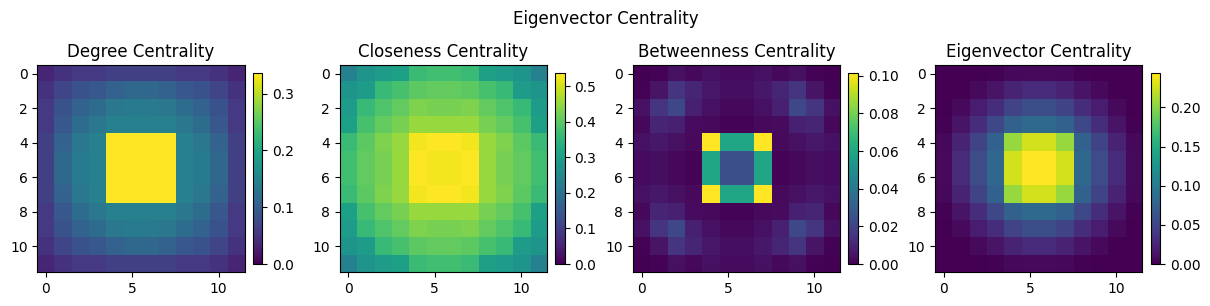

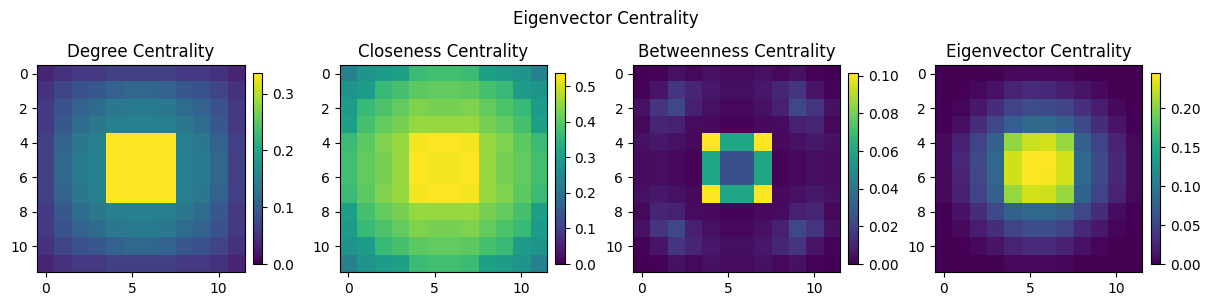

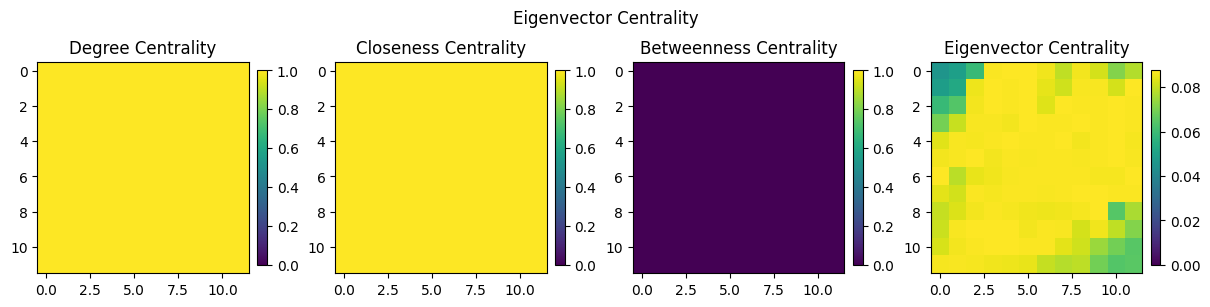

In [6]:
graph_metrics = get_graph_metrics(G)
graph_metrics_eff = get_graph_metrics(G_eff)
graph_metrics_C_avg = get_graph_metrics(G_C_avg)

plot_graph_metrics(graph_metrics,grid_shape=grid_shape,title="Base coupling network metrics")
plot_graph_metrics(graph_metrics_eff,grid_shape=grid_shape,title="Effective coupling network metrics")
plot_graph_metrics(graph_metrics_C_avg,grid_shape=grid_shape,title="Functional connectivity network metrics")

### 2) Adjoint metrics

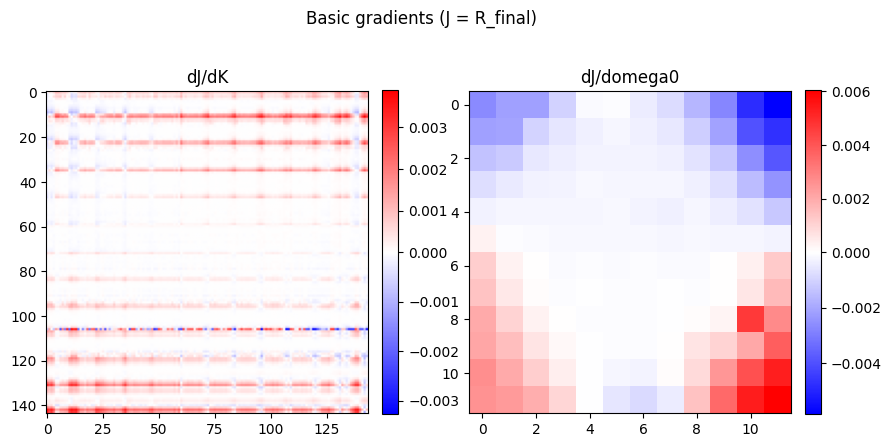

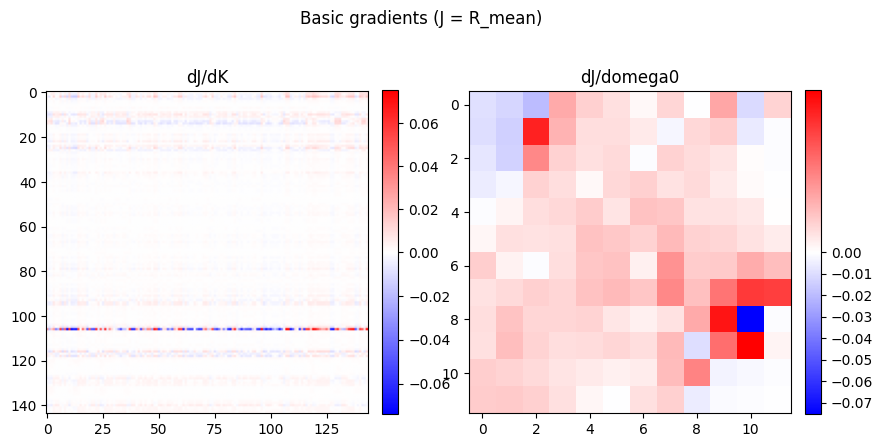

In [7]:
t0, t1 = 0.0, T_END
ts = jnp.arange(t0, t1 + dt / 2, dt)
ts = ts[ts <= t1]

g = grads_final_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=[T_END])
g_avg = grads_mean_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=ts)

plot_basic_grads(g,grid_shape,title="Basic gradients (J = R_final)")
plot_basic_grads(g_avg,grid_shape,title="Basic gradients (J = R_mean)")

  max I_final: 2.463365e-03
  max I_mean: 5.458221e-02
  max |dRf/dalpha| = 2.463365e-03
  max |dRm/dalpha| = 5.458221e-02


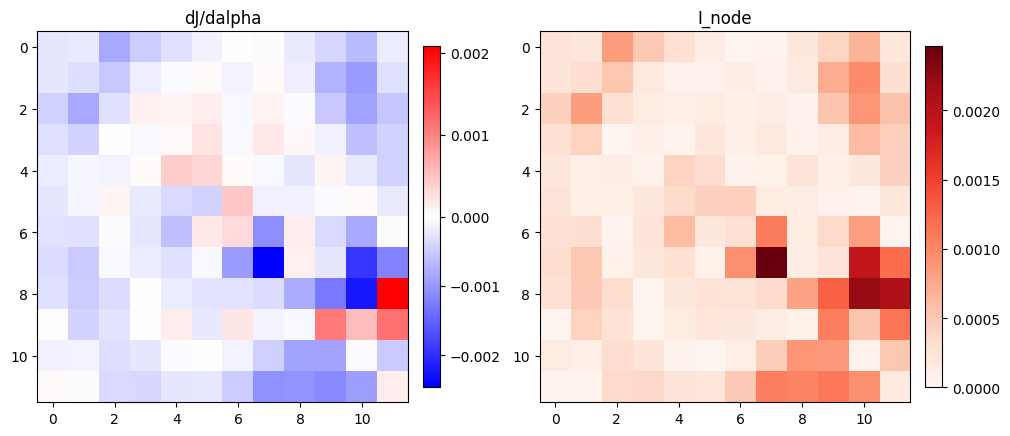

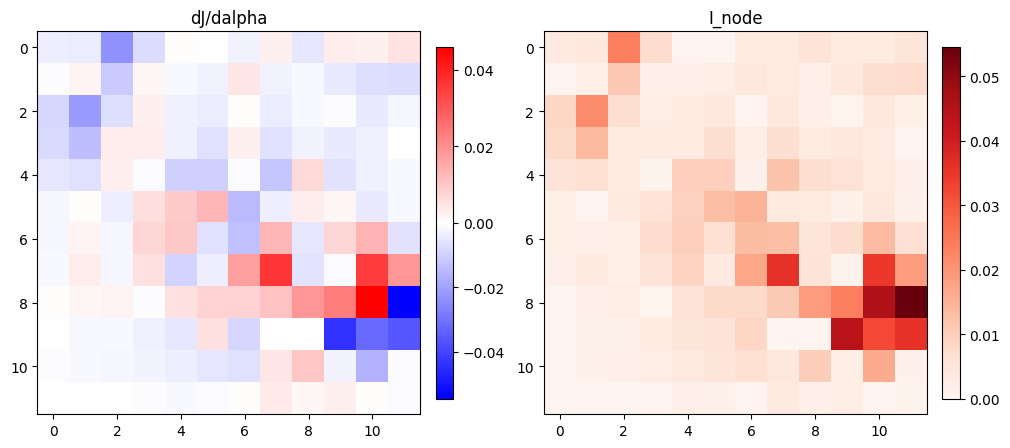

In [8]:
I_final = node_importance_from_gradK(sim.params.K, g.K)
I_mean = node_importance_from_gradK(sim.params.K, g_avg.K)

alpha0 = jnp.zeros((sim.grid.n_total,), dtype=sim.params.K.dtype)
dRf_dalpha = grads_final_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)
dRm_dalpha = grads_mean_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)

#Statistics
print(f"  max I_final: {float(np.max(I_final)):.6e}")
print(f"  max I_mean: {float(np.max(I_mean)):.6e}")
print(f"  max |dRf/dalpha| = {float(np.max(np.abs(dRf_dalpha))):.6e}")
print(f"  max |dRm/dalpha| = {float(np.max(np.abs(dRm_dalpha))):.6e}")

#Plot
plot_advanced_grads(dRf_dalpha, I_final, grid_shape, title="Node importance (J = R_final)")
plot_advanced_grads(dRm_dalpha, I_mean, grid_shape, title="Node importance (J = R_mean)")

## Lesion Studies

In [ ]:
# Assemble all metrics into a single dictionary
metrics = {
    "deg_base": graph_metrics["deg_cent"],
    "deg_eff": graph_metrics_eff["deg_cent"],
    "deg_C_avg": graph_metrics_C_avg["deg_cent"],
    "closeness_base": graph_metrics["closeness"],
    "closeness_eff": graph_metrics_eff["closeness"],
    "closeness_C_avg": graph_metrics_C_avg["closeness"],
    "betweenness_base": graph_metrics["betweenness"],
    "betweenness_eff": graph_metrics_eff["betweenness"],
    "betweenness_C_avg": graph_metrics_C_avg["betweenness"],
    "eigenvector_base": graph_metrics["eigenvector"],
    "eigenvector_eff": graph_metrics_eff["eigenvector"],
    "eigenvector_C_avg": graph_metrics_C_avg["eigenvector"],
    "I_final_base": I_final,
    "I_final_eff": I_mean,
    "I_mean_base": I_mean,
    "I_mean_eff": I_final,
    "dRf_dalpha": dRf_dalpha,
    "dRm_dalpha": dRm_dalpha,
}

K_orig = sim.coupling.K
params_orig = sim.params

### single metric lesion study

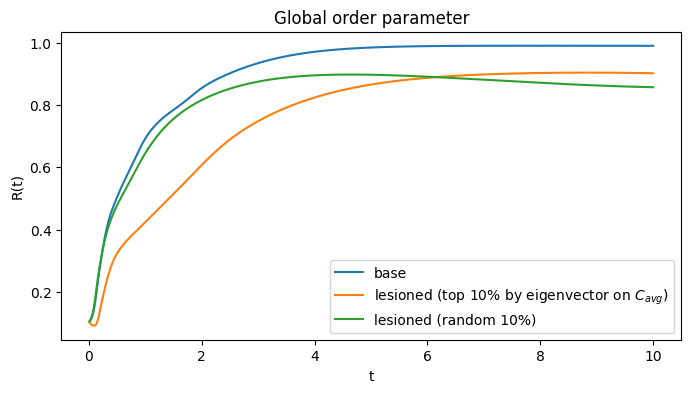

In [ ]:
metric = graph_metrics_C_avg["eigenvector"]

lesion_frac = 0.10
lesion_strength = 1.0 # lesion strength (1.0 = remove all connections)

# --- Lesion top x% of nodes by metric---
ranked_nodes = np.argsort(-np.asarray(metric, dtype=float))

# Find node indices to lesion
n_lesion = max(1, int(round(lesion_frac * N)))
lesion_idx = jnp.asarray(ranked_nodes[:n_lesion], dtype=jnp.int32)

# Create lesion mask
alpha = jnp.zeros((N,), dtype=jnp.float32)
alpha = alpha.at[lesion_idx].set(1.0)

res_ranked_lesion = sim.run_with_lesions(alpha, (0, T_END), dt, rng=RNG)

plot_lesioned_coupling(alpha, K_orig, K_lesioned, title="Lesioned coupling matrix")

# Restore original network
sim.coupling.K = K_orig
sim.params = params_orig

# --- Lesion 10% of nodes randomly ---
# Find node indices to lesion
lesion_idx = RNG.choice(N, size=n_lesion, replace=False)

# Create lesion mask
alpha = jnp.zeros((N,), dtype=jnp.float32)
alpha = alpha.at[lesion_idx].set(1.0)

res_random_lesion = sim.run_with_lesions(alpha, (0, T_END), dt, rng=RNG)

# Compare R vs t for base and lesioned sim
R_base, _ = order_parameter(res_base["theta"])
R_ranked_lesion, _ = order_parameter(res_ranked_lesion["theta"])
R_random_lesion, _ = order_parameter(res_random_lesion["theta"])
ts = res_base["ts"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, R_base, label="base")
ax.plot(ts, R_ranked_lesion, label=f"lesioned (top {lesion_frac:.0%} by eigenvector on $C_{{avg}}$)")
ax.plot(ts, R_random_lesion, label=f"lesioned (random {lesion_frac:.0%})")
ax.set_xlabel("t")
ax.set_ylabel("R(t)")
ax.set_title("Global order parameter")
ax.legend()
plt.show()

In [11]:
# Compute R final/ R_avg vs lesion %
lesion_percentages = np.arange(0, 0.2, 0.01)

R_final_lesioned = []
R_avg_lesioned = []

for lesion_percentage in lesion_percentages:
    # Lesion top x% of nodes
    lesion_nodes = np.argsort(metric)[:int(lesion_percentage * len(metric))]



In [12]:
# Run lesion study for each metric
for metric_name, metric in metrics.items():
    

SyntaxError: incomplete input (3856491262.py, line 3)